In [28]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the stock dataset
dataset = pd.read_csv('stock_clustering_dataset_for_ml.csv')

# Display first 5 rows
dataset.head()

,Ticker,Market_Cap_Cr,Return_1Y_Pct,Volatility_Pct,Beta,PE_Ratio,Dividend_Yield_Pct,Debt_Equity,ROE_Pct,Revenue_Growth_Pct,Profit_Growth_Pct
0,RELIANCE,116840.74,9.00,1.92,1.04,13.94,1.78,0.89,15.23,4.01,7.20
1,ONGC,28083.65,8.04,1.80,1.01,12.73,0.92,0.52,13.79,2.60,1.69
2,IOC,26028.66,9.97,2.04,1.03,12.20,1.04,0.81,15.15,4.28,5.75
3,NTPC,54988.26,5.40,0.77,0.90,15.96,0.84,1.06,7.98,0.31,4.00
4,POWERGRID,38049.71,6.74,0.95,0.76,15.65,1.02,0.48,14.28,4.39,-0.03


In [29]:
# Select numerical features for clustering
X = dataset.iloc[:, 1:].values

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Scale the features so all columns have similar importance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display scaled data
X_scaled

array([[ 1.84255658e+00, -3.05911354e-01, -6.89528440e-01,
        -2.93670707e-01, -9.59110124e-01,  8.60165846e-01,
        -1.87813450e-01,  2.74387781e-01, -7.95277302e-01,
         2.92540549e-01],
       [-9.59479066e-01, -7.38900517e-01, -8.37152727e-01,
        -4.07349690e-01, -1.07201247e+00, -1.52610070e+00,
        -7.88167457e-01, -2.95357576e-01, -1.54010692e+00,
        -1.39619536e+00],
       [-1.02435451e+00,  1.31588113e-01, -5.41904153e-01,
        -3.31563701e-01, -1.12146557e+00, -1.19313327e+00,
        -3.17619721e-01,  2.42735261e-01, -6.52650353e-01,
        -1.51863638e-01],
       [-1.10108316e-01, -1.92962071e+00, -2.10426119e+00,
        -8.24172629e-01, -7.70628516e-01, -1.74807898e+00,
         8.80248781e-02, -2.59412183e+00, -2.74979475e+00,
        -6.88213518e-01],
       [-6.44853437e-01, -1.32524001e+00, -1.88282476e+00,
        -1.35467455e+00, -7.99553911e-01, -1.24862784e+00,
        -8.53070593e-01, -1.01485892e-01, -5.94543077e-01,
        -1.

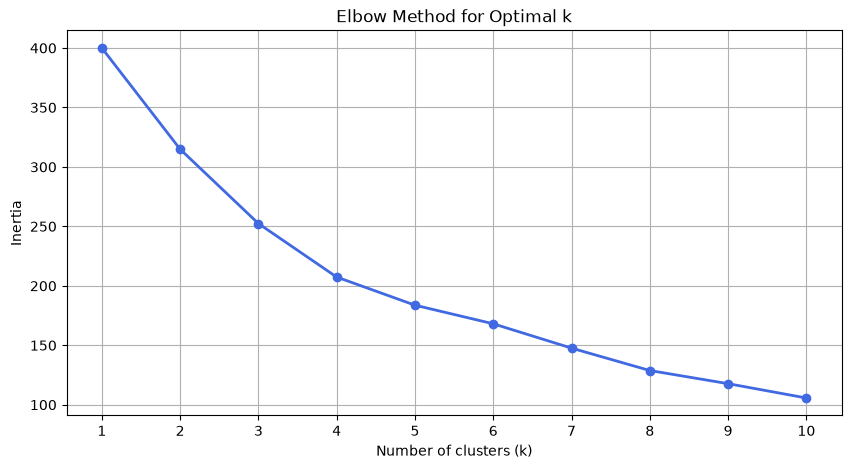

In [30]:
# Elbow curve to find the optimal number of clusters
inertia = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_values, inertia, marker='o', linewidth=2, color='royalblue')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.xticks(list(k_values))
plt.show()

In [31]:
# Import KMeans algorithm
from sklearn.cluster import KMeans

# Create KMeans model with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Train the model and assign each stock to a cluster
dataset['Cluster'] = kmeans.fit_predict(X_scaled) + 1

# Display stock name and its cluster
dataset[['Ticker', 'Cluster']]

,Ticker,Cluster
0,RELIANCE,5
1,ONGC,2
2,IOC,2
3,NTPC,2
4,POWERGRID,2
5,TCS,1
6,INFY,1
7,HCLTECH,1
8,WIPRO,1
9,TECHM,1


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
# Display stocks belonging to each cluster
for cluster in sorted(dataset['Cluster'].unique()):
    
    print(f"\nCluster {cluster}:")
    
    # Get stocks from the current cluster
    print(dataset[dataset['Cluster'] == cluster]['Ticker'].tolist())


Cluster 1:
['TCS', 'INFY', 'HCLTECH', 'WIPRO', 'TECHM', 'TATAMOTORS', 'M&M', 'MARUTI', 'HEROMOTOCO', 'SUNPHARMA', 'DRREDDY', 'DIVISLAB', 'AUROPHARMA']

Cluster 2:
['ONGC', 'IOC', 'NTPC', 'POWERGRID', 'VEDL']

Cluster 3:
['HINDUNILVR', 'ITC', 'NESTLEIND', 'BRITANNIA', 'MARICO']

Cluster 4:
['TATASTEEL']

Cluster 5:
['RELIANCE', 'HDFCBANK', 'ICICIBANK', 'SBIN', 'KOTAKBANK', 'AXISBANK', 'EICHERMOT', 'CIPLA', 'JSWSTEEL', 'HINDALCO', 'COALINDIA', 'LT', 'ADANIPORTS', 'ULTRACEMCO', 'GRASIM', 'SHREECEM']


In [34]:
# Cluster centroids in the original feature scale
feature_cols = dataset.columns[1:-1]

centroid_df = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=feature_cols
)
centroid_df.index = [f"Cluster {i}" for i in range(1, len(centroid_df) + 1)]

centroid_df.round(2)

,Market_Cap_Cr,Return_1Y_Pct,Volatility_Pct,Beta,PE_Ratio,Dividend_Yield_Pct,Debt_Equity,ROE_Pct,Revenue_Growth_Pct,Profit_Growth_Pct
Cluster 1,56344.50,12.20,2.66,1.15,28.88,1.73,0.85,16.50,7.16,8.71
Cluster 2,33851.03,7.37,1.83,1.03,13.45,1.00,0.73,12.20,2.76,3.04
Cluster 3,71389.13,8.71,1.58,0.63,41.73,1.05,0.95,15.07,3.80,5.64
Cluster 4,98984.22,6.67,5.20,1.75,12.24,1.45,4.40,11.27,4.76,3.83
Cluster 5,61336.14,8.84,2.65,1.23,19.08,1.54,1.02,13.70,5.62,5.58
